In [165]:
import pandas as pd 
import numpy as np 
from sklearn.linear_model import Lasso
from scipy.stats import norm
import os
from sklearn.model_selection import KFold

In [166]:
data_path = os.path.join("Data", "acemoglu64.csv")
dat = pd.read_csv(data_path)

# Drop imr95 and leb95
dat = dat.drop(columns=["imr95", "leb95"], errors="ignore")

print(f"The data contains {dat.shape[0]} rows (countries) and {dat.shape[1]} columns (variables).")


The data contains 58 rows (countries) and 43 columns (variables).


In [167]:
Y = dat['logpgp95']
A = dat['avexpr']
Z = dat['logem4']
X = dat.drop(columns=['logpgp95','avexpr','logem4'])

In [168]:
def standardize(X):
    X = np.asarray(X, dtype=float)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, ddof=1, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / sd

def BCCH(X_tilde, y, c=1.1, alpha=0.05):
    X_tilde = np.asarray(X_tilde, dtype=float)
    y = np.asarray(y, dtype=float).flatten()
    N, p = X_tilde.shape    

    yXscale = (np.max((X_tilde.T ** 2) @ ((y-np.mean(y)) ** 2) / N)) ** 0.5
    lambda_pilot = c*norm.ppf(1-alpha/(2*p))*yXscale/np.sqrt(N)
    
    pred = Lasso(alpha=lambda_pilot).fit(X_tilde,y).predict(X_tilde)

    res = y - pred
    resXscale = (np.max((X_tilde.T ** 2) @ (res ** 2) / N)) ** 0.5
    lambda_bcch = c*norm.ppf(1-alpha/(2*p))*resXscale/np.sqrt(N)

    return lambda_bcch

In [169]:
X_tilde = standardize(X)


In [170]:
print("X_tilde shape:", X_tilde.shape)
print("Any NaN in X_tilde?", np.isnan(X_tilde).any())



X_tilde shape: (58, 40)
Any NaN in X_tilde? False


In [171]:
alpha = 0.05
#alpha = 0.1/np.log(58)  
# 1st LASSO: Y on X
lambda_Y = BCCH(X_tilde, Y, alpha=alpha)
lasso_Y = Lasso(alpha=lambda_Y, max_iter=12000).fit(X_tilde, Y)
coefs_Y = lasso_Y.coef_
sel_Y = np.where(coefs_Y != 0)[0]
# 2nd LASSO: A on X
lambda_A = BCCH(X_tilde, A, alpha=alpha) 
lasso_A = Lasso(alpha=lambda_A, max_iter=12000).fit(X_tilde, A)
coefs_A = lasso_A.coef_
sel_A = np.where(coefs_A != 0)[0]
# 3rd LASSO: Z on X
lambda_Z = BCCH(X_tilde, Z, alpha=alpha)
lasso_Z = Lasso(alpha=lambda_Z, max_iter=12000).fit(X_tilde, Z)
coefs_Z = lasso_Z.coef_
sel_Z = np.where(coefs_Z != 0)[0]
# Union of selected variables
sel_union = np.union1d(sel_Y, np.union1d(sel_A, sel_Z))
print(f'Selected variables indices: {sel_union}')

Selected variables indices: []


In [172]:
from sklearn.linear_model import Lasso
from scipy.stats import norm
import numpy as np

def BCCH_diag(X_tilde, y, c=1.1, alpha=0.05, max_iter=10000):
    # Make sure inputs are nice
    X_tilde = np.asarray(X_tilde, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    N, p = X_tilde.shape

    if p == 0:
        raise ValueError("X_tilde must have at least one column.")
    if N != y.shape[0]:
        raise ValueError(f"Row mismatch: X_tilde has {N} rows, y has {y.shape[0]}.")

    if not np.isfinite(X_tilde).all():
        raise ValueError("X_tilde contains NaN or inf.")
    if not np.isfinite(y).all():
        raise ValueError("y contains NaN or inf.")

    # Quantile term
    quant = norm.ppf(1 - alpha / (2 * p))

    # Pilot scale based on y
    y_centered = y - y.mean()
    yXscale = np.sqrt(np.max((X_tilde ** 2).T @ (y_centered ** 2) / N))
    lambda_pilot = c * quant * yXscale / np.sqrt(N)

    print("=== BCCH diagnostics ===")
    print(f"N             = {N}")
    print(f"p             = {p}")
    print(f"quantile term = {quant:.6f}")
    print(f"yXscale       = {yXscale:.6f}")
    print(f"lambda_pilot  = {lambda_pilot:.6f}")

    # Pilot Lasso
    fit_pilot = Lasso(alpha=lambda_pilot, max_iter=max_iter).fit(X_tilde, y)
    eps = y - fit_pilot.predict(X_tilde)

    # Final scale based on residuals
    epsXscale = np.sqrt(np.max((X_tilde ** 2).T @ (eps ** 2) / N))
    lambda_bcch = c * quant * epsXscale / np.sqrt(N)

    print(f"epsXscale     = {epsXscale:.6f}")
    print(f"lambda_bcch   = {lambda_bcch:.6f}")
    print("=========================\n")

    return float(lambda_bcch)
# Compute BCCH penalty with diagnostics
lambda_Y = BCCH_diag(X_tilde, Y)

# Fit Lasso and see selection
lasso_Y = Lasso(alpha=lambda_Y, max_iter=12000).fit(X_tilde, Y)
coefs_Y = lasso_Y.coef_
selected = np.where(coefs_Y != 0)[0]

print("BCCH lambda_Y:", lambda_Y)
print("Number of selected variables:", len(selected))
print("Selected indices:", selected)
for f in [1.0, 0.8, 0.2, 0.1]:
    lmb = lambda_Y * f
    lasso_tmp = Lasso(alpha=lmb, max_iter=12000).fit(X_tilde, Y)
    k_sel = np.sum(lasso_tmp.coef_ != 0)
    print(f"alpha = {lmb:.6f}, selected = {k_sel}")


=== BCCH diagnostics ===
N             = 58
p             = 40
quantile term = 3.227218
yXscale       = 1.850393
lambda_pilot  = 0.862523
epsXscale     = 1.850393
lambda_bcch   = 0.862523

BCCH lambda_Y: 0.862523457144565
Number of selected variables: 0
Selected indices: []
alpha = 0.862523, selected = 0
alpha = 0.690019, selected = 1
alpha = 0.172505, selected = 5
alpha = 0.086252, selected = 10


In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.exceptions import ConvergenceWarning
import warnings
from statsmodels.sandbox.regression.gmm import IV2SLS

# ============================================================
# 1. Baseline setup
# ============================================================

c0 = 1.1              # keep c fixed
N, p = X_tilde.shape

# Grid of alpha values to explore
alpha_grid = np.arange(0.1/np.log(N), 0.8, 0.01)  # adjust range/step as you like

betas = []
ses = []
union_sizes = []
union_sets = []
conds = []

alpha_values = []

lam_Y_list = []
lam_A_list = []
lam_Z_list = []

# ============================================================
# 2. Loop over alpha
# ============================================================

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    for alpha in alpha_grid:
        # Recompute BCCH lambdas for this alpha
        lam_Y = float(BCCH(X_tilde, Y, c=c0, alpha=alpha))
        lam_A = float(BCCH(X_tilde, A, c=c0, alpha=alpha))
        lam_Z = float(BCCH(X_tilde, Z, c=c0, alpha=alpha))

        lam_Y_list.append(lam_Y)
        lam_A_list.append(lam_A)
        lam_Z_list.append(lam_Z)
        alpha_values.append(alpha)

        # 3 LASSOs
        lasso_y = Lasso(alpha=lam_Y, max_iter=80000, tol=1e-7).fit(X_tilde, Y)
        lasso_a = Lasso(alpha=lam_A, max_iter=80000, tol=1e-7).fit(X_tilde, A)
        lasso_z = Lasso(alpha=lam_Z, max_iter=80000, tol=1e-7).fit(X_tilde, Z)

        S_y = set(np.where(lasso_y.coef_ != 0)[0])
        S_a = set(np.where(lasso_a.coef_ != 0)[0])
        S_z = set(np.where(lasso_z.coef_ != 0)[0])

        S_union = sorted(S_y | S_a | S_z)
        union_sets.append(S_union)
        union_sizes.append(len(S_union))

        # Controls matrix for this alpha
        X_union = X_tilde[:, S_union] if S_union else np.empty((N, 0))

        # 2SLS with union controls
        if X_union.size > 0:
            exog = np.column_stack([np.ones(N), A, X_union])
            instr = np.column_stack([np.ones(N), Z, X_union])
        else:
            exog = np.column_stack([np.ones(N), A])
            instr = np.column_stack([np.ones(N), Z])

        # Condition number of X' Pz X
        Zm = instr
        Pz = Zm @ np.linalg.inv(Zm.T @ Zm) @ Zm.T
        XPZX = exog.T @ Pz @ exog
        cond_val = np.linalg.cond(XPZX)
        conds.append(cond_val)

        # 2SLS estimate + SE
        try:
            iv = IV2SLS(Y, exog, instr).fit()
            beta_hat = float(iv.params.iloc[1])   # coef on A
            se_hat   = float(iv.bse.iloc[1])      # SE on coef
        except Exception:
            beta_hat = np.nan
            se_hat   = np.nan

        betas.append(beta_hat)
        ses.append(se_hat)

# ============================================================
# 3. Convert to arrays, compute CI
# ============================================================

alpha_values = np.array(alpha_values)
betas = np.array(betas)
ses = np.array(ses)
union_sizes = np.array(union_sizes)
conds = np.array(conds)

lam_Y_arr = np.array(lam_Y_list)
lam_A_arr = np.array(lam_A_list)
lam_Z_arr = np.array(lam_Z_list)

ci_low = betas - 1.96 * ses
ci_high = betas + 1.96 * ses

# ============================================================
# 4. "Reasonable region": basic sanity
# ============================================================

stable_mask = (
    np.isfinite(betas) &
    np.isfinite(ses) &
    (ses < 10) &
    (conds < 1e7)
)

df_stable = pd.DataFrame({
    "alpha": alpha_values,
    "beta_hat": betas,
    "se_beta": ses,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "union_size": union_sizes,
    "cond_number": conds,
    "union_idx": union_sets,
})[stable_mask].reset_index(drop=True)

# ============================================================
# 4b. Collapse to regimes (unique selection sets)
# ============================================================

# Convert union_idx lists → tuples so groupby can hash them
df_stable["union_idx"] = df_stable["union_idx"].apply(lambda x: tuple(x))

df_reg = (
    df_stable
    .groupby("union_idx", as_index=False)
    .agg(
        alpha_min=("alpha", "min"),
        alpha_max=("alpha", "max"),
        alpha_mid=("alpha", "mean"),       # x-position for plotting
        beta_rep=("beta_hat", "mean"),
        ci_low_rep=("ci_low", "mean"),
        ci_high_rep=("ci_high", "mean"),
        union_size=("union_size", "first"),
    )
    .sort_values("alpha_mid")
    .reset_index(drop=True)
)



# Extract arrays for plotting
alpha_mid   = df_reg["alpha_mid"].to_numpy()
beta_rep    = df_reg["beta_rep"].to_numpy()
ci_low_rep  = df_reg["ci_low_rep"].to_numpy()
ci_high_rep = df_reg["ci_high_rep"].to_numpy()
union_reg   = df_reg["union_size"].to_numpy()
alpha_min   = df_reg["alpha_min"].to_numpy()
alpha_max   = df_reg["alpha_max"].to_numpy()

# Build step plot ranges for union size (constant in [alpha_min, alpha_max])
alpha_step = np.empty(2 * len(df_reg))
alpha_step[0::2] = alpha_min
alpha_step[1::2] = alpha_max
union_step = np.repeat(union_reg, 2)

# y-error bars
yerr_lower = beta_rep - ci_low_rep
yerr_upper = ci_high_rep - beta_rep
yerr = np.vstack([yerr_lower, yerr_upper])



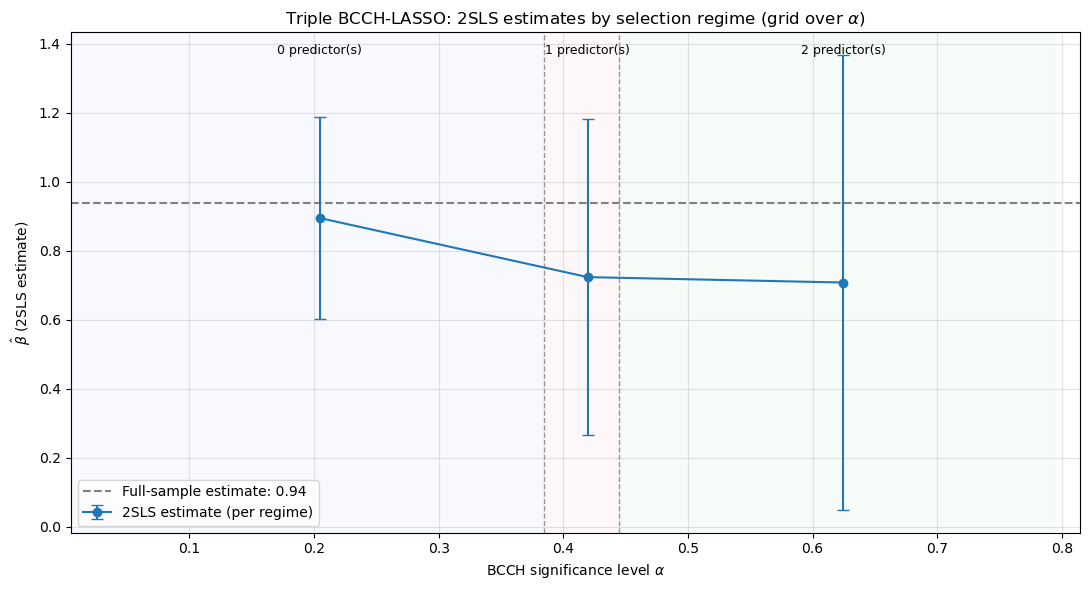

In [174]:
from matplotlib.patches import Patch

# df_reg contains:
# alpha_min, alpha_max, alpha_mid, beta_rep, ci_low_rep, ci_high_rep, union_size

df_reg_sorted = df_reg.sort_values("alpha_min").reset_index(drop=True)

alpha_mid   = df_reg_sorted["alpha_mid"].to_numpy()
beta_rep    = df_reg_sorted["beta_rep"].to_numpy()
ci_low_rep  = df_reg_sorted["ci_low_rep"].to_numpy()
ci_high_rep = df_reg_sorted["ci_high_rep"].to_numpy()
union_reg   = df_reg_sorted["union_size"].to_numpy()

yerr_lower = beta_rep - ci_low_rep
yerr_upper = ci_high_rep - beta_rep
yerr = np.vstack([yerr_lower, yerr_upper])

beta_full = 0.94

plt.figure(figsize=(11, 6))
ax1 = plt.gca()

# ------------------------------------------------------------
# X-range (ensure all regimes visible)
# ------------------------------------------------------------
x_left = df_reg_sorted["alpha_min"].min() - 0.02
x_right = df_reg_sorted["alpha_max"].max() + 0.02
ax1.set_xlim(x_left, x_right)

# ------------------------------------------------------------
# 1) Seamless regime blocks
# ------------------------------------------------------------
colors = ["#eef3ff", "#fdeef0", "#eef8ee"]  # alternating light pastels

L = x_left
for i, row in df_reg_sorted.iterrows():
    R = row["alpha_max"]

    ax1.axvspan(L, R, color=colors[i % len(colors)], alpha=0.45, zorder=0)

    if i > 0:
        ax1.axvline(
            L, color="grey", linestyle="--", linewidth=1.0, alpha=0.8, zorder=1
        )

    L = R

# ------------------------------------------------------------
# 2) β(α) with CI
# ------------------------------------------------------------
ax1.errorbar(
    alpha_mid, beta_rep,
    yerr=yerr,
    fmt="o-",
    linewidth=1.5,
    markersize=6,
    capsize=4,
    color="tab:blue",
    label="2SLS estimate (per regime)",
    zorder=2,
)

# Full-sample beta
ax1.axhline(
    beta_full, linestyle="--", color="grey", linewidth=1.5,
    label=f"Full-sample estimate: {beta_full:.2f}",
    zorder=1.5,
)

ax1.set_xlabel(r"BCCH significance level $\alpha$")
ax1.set_ylabel(r"$\hat{\beta}$ (2SLS estimate)")
ax1.grid(True, which="both", alpha=0.35)

# ------------------------------------------------------------
# 3) Regime labels centered above blocks, using “predictor(s)”
# ------------------------------------------------------------
ymin, ymax = ax1.get_ylim()
ax1.set_ylim(min(0, ymin), max(0, ymax))

ymin, ymax = ax1.get_ylim()
label_y = ymax - 0.05 * (ymax - ymin)

for i, row in df_reg_sorted.iterrows():
    L = df_reg_sorted.loc[i, "alpha_min"]
    R = df_reg_sorted.loc[i, "alpha_max"]
    x_center = 0.5 * (L + R)
    k = union_reg[i]

    ax1.text(
        x_center,
        label_y,
        f"{k} predictor(s)",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

# ------------------------------------------------------------
# 4) Legend relocated to avoid label overlap
# ------------------------------------------------------------
ax1.legend(loc="lower left", frameon=True)

plt.title(r"Triple BCCH-LASSO: 2SLS estimates by selection regime (grid over $\alpha$)")
plt.tight_layout()
plt.show()


In [175]:
# 1) Get variable names from your X DataFrame
X_names = X.columns.to_list()
assert X_tilde.shape[1] == len(X_names), "X_tilde and X.columns length mismatch"

# Helper: indices -> names
def indices_to_names(idxs):
    return [X_names[j] for j in idxs]

# 2) Build one representative row per union_size regime
regime_rows = []
for u in sorted(df_stable["union_size"].unique()):
    sub = df_stable[df_stable["union_size"] == u].sort_values("alpha")
    row = sub.iloc[0]   # take first c in this regime as representative
    idxs = row["union_idx"]          # this is the list of selected column indices
    varnames = indices_to_names(idxs)

    regime_rows.append({
        "union_size": int(u),
        "alpha": float(row["alpha"]),
        "beta_rep": float(row["beta_hat"]),
        "ci_low_rep": float(row["ci_low"]),
        "ci_high_rep": float(row["ci_high"]),
        "variables": varnames
    })

df_regimes = pd.DataFrame(regime_rows).sort_values("alpha").reset_index(drop=True)
display(df_regimes)

# 3) LaTeX table
def latex_escape(s: str) -> str:
    return s.replace("_", r"\_")  # basic escaping; extend if needed

lines = []
lines.append(r"\begin{table}[h]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{ccccp{7cm}}")
lines.append(r"\toprule")
lines.append(r"Regime & $$ & Union size & $\hat\beta_A$ (95\% CI) & Selected controls \\")
lines.append(r"\midrule")

for i, row in df_regimes.iterrows():
    c_val = f"{row['alpha']:.3f}"
    u_sz = int(row["union_size"])
    beta = row["beta_rep"]
    ci_l = row["ci_low_rep"]
    ci_h = row["ci_high_rep"]
    ci_str = f"{beta:.2f} [{ci_l:.2f}, {ci_h:.2f}]"
    if u_sz > 0:
        vars_joined = ", ".join(latex_escape(v) for v in row["variables"])
    else:
        vars_joined = r"(none)"
    lines.append(
        f"{i+1} & {c_val} & {u_sz} & {ci_str} & {vars_joined} \\\\"
    )

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Triple BCCH-LASSO selection regimes for $c>0.65$, "
             r"showing union size, 2SLS estimate of $A$, and selected controls.}")
lines.append(r"\label{tab:bcch_regimes}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)



,union_size,alpha,beta_rep,ci_low_rep,ci_high_rep,variables
0,0,0.024628,0.894945,0.601678,1.188212,[]
1,1,0.394628,0.723791,0.266598,1.180985,[malfal94]
2,2,0.454628,0.708127,0.048889,1.367364,"[edes1975, malfal94]"


\begin{table}[h]
\centering
\begin{tabular}{ccccp{7cm}}
\toprule
Regime & $$ & Union size & $\hat\beta_A$ (95\% CI) & Selected controls \\
\midrule
1 & 0.025 & 0 & 0.89 [0.60, 1.19] & (none) \\
2 & 0.395 & 1 & 0.72 [0.27, 1.18] & malfal94 \\
3 & 0.455 & 2 & 0.71 [0.05, 1.37] & edes1975, malfal94 \\
\bottomrule
\end{tabular}
\caption{Triple BCCH-LASSO selection regimes for $c>0.65$, showing union size, 2SLS estimate of $A$, and selected controls.}
\label{tab:bcch_regimes}
\end{table}


In [176]:
# Example: list of column names for X_tilde in order
X_names = X.columns.to_list()  # e.g. ["africa", "lat_abst", "other", "asia", ..., "lt100km", "latabs"]

name_to_idx = {name: j for j, name in enumerate(X_names)}

blocks = {
    "region_colonial": [
        "africa", "asia", "other", "rich4",
        "f_brit", "f_french", "sjlofr",
    ],
    "culture_religion": [
        "catho80", "muslim80", "no_cpm80", "avelf", "edes1975",
    ],
    "climate": [
        "lat_abst", "latabs",
        "temp1", "temp2", "temp3", "temp4", "temp5",
        "humid1", "humid2", "humid3", "humid4",
        "meantemp", "drystep", "drywint",
    ],
    "soil_terrain": [
        "steplow", "deslow", "stepmid", "desmid",
    ],
    "geography": [
        "landlock", "lt100km",
    ],
    "resources": [
        "goldm", "iron", "silv", "zinc", "oilres",
    ],
    "disease": [
        "malfal94", "yellow",
    ]}


In [177]:
import warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.exceptions import ConvergenceWarning
from statsmodels.sandbox.regression.gmm import IV2SLS

# ------------------------------------------------------------
# Assumes you already have:
# - blocks: dict[block_name -> list of varnames]
# - name_to_idx: dict[varname -> column index in X_tilde]
# - X_names: list of variable names in order of X_tilde columns
# - X_tilde, Y, A, Z, BCCH defined
# ------------------------------------------------------------

global_selected = set()
block_rows = []   # for LaTeX: one row per block

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    for block_name, varnames in blocks.items():
        idxs = [name_to_idx[v] for v in varnames if v in name_to_idx]
        if not idxs:
            continue

        X_block = X_tilde[:, idxs]

        # One lambda per equation (BCCH on the block)
        lam_Y = float(BCCH(X_block, Y))
        lam_A = float(BCCH(X_block, A))
        lam_Z = float(BCCH(X_block, Z))

        # Triple LASSO on this block
        lasso_y = Lasso(alpha=lam_Y, max_iter=80000, tol=1e-7).fit(X_block, Y)
        lasso_a = Lasso(alpha=lam_A, max_iter=80000, tol=1e-7).fit(X_block, A)
        lasso_z = Lasso(alpha=lam_Z, max_iter=80000, tol=1e-7).fit(X_block, Z)

        S_y = set(np.where(lasso_y.coef_ != 0)[0])
        S_a = set(np.where(lasso_a.coef_ != 0)[0])
        S_z = set(np.where(lasso_z.coef_ != 0)[0])

        # Indices relative to full X_tilde:
        S_block_union = {idxs[j] for j in (S_y | S_a | S_z)}

        # Variable names for this block's selection
        selected_names = [X_names[j] for j in sorted(S_block_union)]

        # Append to rows for LaTeX (comma-separated list or "(none)")
        block_rows.append({
            "Block": block_name,
            "Selected controls": ", ".join(selected_names) if selected_names else "(none)"
        })

        global_selected |= S_block_union

# ------------------ Final union & 2SLS ----------------------

global_selected = sorted(global_selected)
global_selected_names = [X_names[j] for j in global_selected]

N = X_tilde.shape[0]
X_union = X_tilde[:, global_selected] if global_selected else np.empty((N, 0))

if X_union.size > 0:
    exog = np.column_stack([np.ones(N), A, X_union])
    instr = np.column_stack([np.ones(N), Z, X_union])
else:
    exog = np.column_stack([np.ones(N), A])
    instr = np.column_stack([np.ones(N), Z])

iv_final = IV2SLS(Y, exog, instr).fit()
beta_final = float(iv_final.params.iloc[1])
se_final = float(iv_final.bse.iloc[1])

# ------------------ Build LaTeX tables ----------------------

# 1) Block-wise selected controls table
df_blocks = pd.DataFrame(block_rows)

latex_blocks = df_blocks.to_latex(
    index=False,
    escape=True,  # escape underscores in names
    caption="Block-wise LASSO-selected controls",
    label="tab:block_lasso"
)

print(latex_blocks)

# 2) Global selected controls table (one variable per row)
df_global = pd.DataFrame({
    "Selected control": global_selected_names
})

latex_global = df_global.to_latex(
    index=False,
    escape=True,
    caption="Global union of LASSO-selected controls across blocks",
    label="tab:global_lasso"
)

print(latex_global)

# 3) Final 2SLS result table
df_iv = pd.DataFrame({
    "Coefficient on A": [beta_final],
    "Std. error": [se_final]
})

latex_iv = df_iv.to_latex(
    index=False,
    float_format="%.3f",
    caption="Final 2SLS estimate after blockwise LASSO selection",
    label="tab:iv_block_lasso"
)

print(latex_iv)

# Optional: if you want the strings for later use:
# with open("lasso_block_tables.tex", "w") as f:
#     f.write(latex_blocks + "\n\n" + latex_global + "\n\n" + latex_iv)


\begin{table}
\caption{Block-wise LASSO-selected controls}
\label{tab:block_lasso}
\begin{tabular}{ll}
\toprule
Block & Selected controls \\
\midrule
region\_colonial & (none) \\
culture\_religion & edes1975 \\
climate & (none) \\
soil\_terrain & (none) \\
geography & (none) \\
resources & (none) \\
disease & malfal94 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Global union of LASSO-selected controls across blocks}
\label{tab:global_lasso}
\begin{tabular}{l}
\toprule
Selected control \\
\midrule
edes1975 \\
malfal94 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Final 2SLS estimate after blockwise LASSO selection}
\label{tab:iv_block_lasso}
\begin{tabular}{rr}
\toprule
Coefficient on A & Std. error \\
\midrule
0.708 & 0.336 \\
\bottomrule
\end{tabular}
\end{table}

